# Formula 1: Constructor Performance, 1981-2020

**DATASCI 530 - Assignment 2**\
**Author:** Xueqian Cheng

## Summary of findings

The top three constructors that dominated the 1981-2020 period are Ferrari, Mercedes, and McLaren, and they are Ferrari, Mercedes, and Red Bull for the 2001-2020 period. The rankings of the top constructors almost stayed identical over the past 40 years, while the leading teams became more dominant: the top three won 60% of all points in 2001-2020, compared with 51% over 1981-2020. Ferrari, the most successful constructor in both periods, had 25 different drivers between 1981 and 2020, and its best season was 2002, when it won half of all points awarded and 15 of the 17 races. Finally, most drivers do not stay with one team: only 36% of drivers raced for a single team, and no driver with a career of six or more seasons stayed with the same team the whole time.

## Data and methodology

The analysis uses the Formula 1 World Championship dataset (1950-2020) introduced in Lecture 3. I used the races, results, constructors, and drivers dataset and did not find any missing values.

---
## 0. Setup

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## 1. Load the data


In [69]:
results      = pd.read_csv("../Lecture 03/data_raw/results.csv",      na_values="\\N")
races        = pd.read_csv("../Lecture 03/data_raw/races.csv",        na_values="\\N")
constructors = pd.read_csv("../Lecture 03/data_raw/constructors.csv", na_values="\\N")
drivers      = pd.read_csv("../Lecture 03/data_raw/drivers.csv",      na_values="\\N")

print("results:     ", results.shape)
print("races:       ", races.shape)
print("constructors:", constructors.shape)
print("drivers:     ", drivers.shape)

results:      (25840, 18)
races:        (1102, 18)
constructors: (211, 5)
drivers:      (857, 9)


In [70]:
# What does one row of each table look like?
results.head(3)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1


### 1.1 Check for missing values

In [71]:
print("Missing values in results:")
print(results[["raceId", "driverId", "constructorId", "points"]].isna().sum())

print("\nMissing values in races:")
print(races[["raceId", "year"]].isna().sum())

Missing values in results:
raceId           0
driverId         0
constructorId    0
points           0
dtype: int64

Missing values in races:
raceId    0
year      0
dtype: int64


There are no missing values in the columns we are going to analyze in the results and races data.

---
## 2. Put the tables together

`results` has the points, but not the season year, the constructor name, or the driver
name. Those live in the other three tables, so I merged them in one.

In [72]:
# Step 1: add the season year from races
races_small = races[["raceId", "year", "round"]]
f1 = results.merge(races_small, on="raceId", how="left")

print("rows in results:", len(results))
print("rows after merge:", len(f1))

rows in results: 25840
rows after merge: 25840


In [73]:
# Step 2: add the constructor name
# The column is called "name" in constructors, so rename it to something clearer first.
constructors_small = constructors[["constructorId", "name"]]
constructors_small = constructors_small.rename(columns={"name": "constructor"})

f1 = f1.merge(constructors_small, on="constructorId", how="left")

print("rows after merge:", len(f1))
print("rows with no constructor name:", f1["constructor"].isna().sum())

rows after merge: 25840
rows with no constructor name: 0


In [74]:
# Step 3: add the driver name, then combine first and last name into one column
drivers_small = drivers[["driverId", "forename", "surname"]]
f1 = f1.merge(drivers_small, on="driverId", how="left")
f1["driver"] = f1["forename"] + " " + f1["surname"]

print("rows after merge:", len(f1))
print("rows with no driver name:", f1["driver"].isna().sum())

f1[["year", "constructor", "driver", "points"]].head(3)

rows after merge: 25840
rows with no driver name: 0


,year,constructor,driver,points
0,2008,McLaren,Lewis Hamilton,10.0
1,2008,BMW Sauber,Nick Heidfeld,8.0
2,2008,Williams,Nico Rosberg,6.0


---
## 3. (a) Top three constructors, 1981-2020

The top three constructors that earned the most points between 1981 and 2020 are Ferrari, Mercedes, and McLaren. As a reference level, average points that all constructors earned between 1981 and 2020 are 532. The top three constructors earned 10 to 14 times the average level.

In [75]:
# Keep only the seasons we want
period_a = f1[(f1["year"] >= 1981) & (f1["year"] <= 2020)]

# Add up the points each constructor scored, then sort from highest to lowest
points_a = period_a.groupby("constructor")["points"].sum()
points_a = points_a.sort_values(ascending=False)
points_a = points_a.reset_index() 
points_a.head(10)

,constructor,points
0,Ferrari,7374.0
1,Mercedes,5685.0
2,McLaren,5229.5
3,Red Bull,5043.5
4,Williams,3355.0
5,Renault,1710.0
6,Force India,1098.0
7,Benetton,861.5
8,Lotus F1,706.0
9,Sauber,557.0


In [76]:
# Compare the top three with the average constructor
average_a = points_a["points"].mean()

top3_a = points_a.head(3).copy()
top3_a["times_average"] = top3_a["points"] / average_a

print("Number of constructors that raced in 1981-2020:", len(points_a))
print("Average points per constructor:", round(average_a, 1))

top3_a.round(1)

Number of constructors that raced in 1981-2020: 67
Average points per constructor: 532.2


,constructor,points,times_average
0,Ferrari,7374.0,13.9
1,Mercedes,5685.0,10.7
2,McLaren,5229.5,9.8


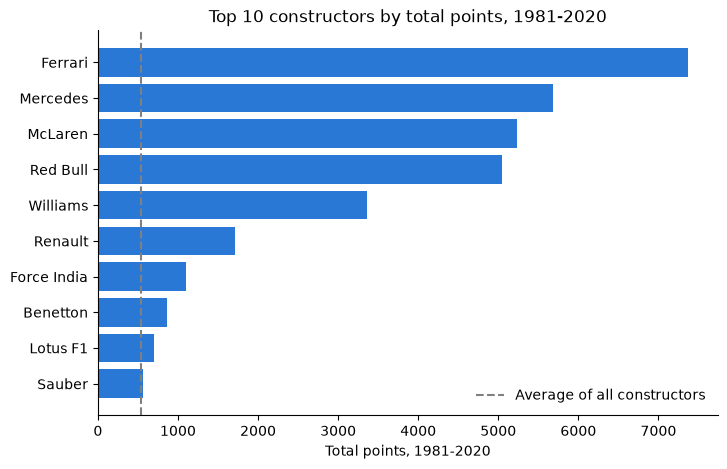

In [77]:
# Bar chart: total points for the top 10 constructors, with a line at the average
top10_a = points_a.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10_a["constructor"], top10_a["points"], color="#2a78d6")
plt.gca().invert_yaxis()                  # highest total at the top
plt.axvline(average_a, color="grey", linestyle="--", label="Average of all constructors")
plt.xlabel("Total points, 1981-2020")
plt.title("Top 10 constructors by total points, 1981-2020")
plt.legend(frameon=False)
plt.show()

---
## 4. (b) Top three constructors, 2001-2020

The top three constructors that earned the most points between 2001 and 2020 are Ferrari, Mercedes, and Red Bull. As a reference level, average points that all constructors earned between 2001 and 2020 are 786. The top three constructors earned 6 to 7.5 times the average level. That ratio is lower than for 1981-2020, but it does not mean the gap narrowed: far fewer constructors raced after 2000 (35 vs. 67), which raises the average. Measured by share of all points scored, the top three were actually more dominant after 2000 (60% vs. 51%, see part c).

In [78]:
# Keep only the seasons we want
period_b = f1[(f1["year"] >= 2001) & (f1["year"] <= 2020)]

# Add up the points each constructor scored, then sort from highest to lowest
points_b = period_b.groupby("constructor")["points"].sum()
points_b = points_b.sort_values(ascending=False)
points_b = points_b.reset_index() 
points_b.head(10)

,constructor,points
0,Ferrari,5862.0
1,Mercedes,5685.0
2,Red Bull,5043.5
3,McLaren,3284.0
4,Williams,1535.5
5,Renault,1465.0
6,Force India,1098.0
7,Lotus F1,706.0
8,Toro Rosso,500.0
9,Sauber,467.0


In [79]:
# Compare the top three with the average constructor
average_b = points_b["points"].mean()

top3_b = points_b.head(3).copy()
top3_b["times_average"] = top3_b["points"] / average_b

print("Number of constructors that raced in 2001-2020:", len(points_b))
print("Average points per constructor:", round(average_b, 1))

top3_b.round(1)

Number of constructors that raced in 2001-2020: 35
Average points per constructor: 786.0


,constructor,points,times_average
0,Ferrari,5862.0,7.5
1,Mercedes,5685.0,7.2
2,Red Bull,5043.5,6.4


---
## 5. (c) How did the rankings change across the two periods?

The top of the ranking barely changed. Ferrari and Mercedes are first and second in both periods, and Williams is fifth in both. The only change in the top five is that Red Bull moves up from 4th to 3rd and McLaren drops from 3rd to 4th. The top three also took a larger share of all points in 2001-2020 (60%) than in 1981-2020 (51%), so points became more concentrated among the leading teams.

In [80]:
# The top five constructors in each period, side by side
top5_compare = pd.DataFrame({
    "1981-2020": list(points_a["constructor"].head(5)),
    "2001-2020": list(points_b["constructor"].head(5)),
}, index=[1, 2, 3, 4, 5])
top5_compare.index.name = "Rank"

top5_compare

,1981-2020,2001-2020
Rank,,
1,Ferrari,Ferrari
2,Mercedes,Mercedes
3,McLaren,Red Bull
4,Red Bull,McLaren
5,Williams,Williams


In [81]:
# Share of all points won by the top three teams in each period.
share_a = points_a["points"].head(3).sum() / points_a["points"].sum() * 100
share_b = points_b["points"].head(3).sum() / points_b["points"].sum() * 100

print("Top-3 share of all points, 1981-2020:", round(share_a, 1), "%")
print("Top-3 share of all points, 2001-2020:", round(share_b, 1), "%")

Top-3 share of all points, 1981-2020: 51.3 %
Top-3 share of all points, 2001-2020: 60.3 %


---
## 6. (d) How many different drivers did Ferrari have, 1981-2020?

Ferrari had 25 different drivers between 1981 and 2020. I counted every driver who raced for Ferrari at least once, and counted each driver only once no matter how many seasons they stayed. Four of the 25 drove fewer than five races for the team. These were probably stand-ins who replaced an injured or departing regular driver. Leaving them out would give 21 regular drivers.

In [82]:
# All Ferrari results between 1981 and 2020
ferrari = period_a[period_a["constructor"] == "Ferrari"]

# Count each driver once, no matter how many races they drove
n_drivers = ferrari["driver"].nunique()
print("Different drivers who raced for Ferrari, 1981-2020:", n_drivers)

# How many races did each of them drive for Ferrari?
races_per_driver = ferrari.groupby("driver")["raceId"].nunique()
print("Drivers with fewer than 5 races for Ferrari:", (races_per_driver < 5).sum())

Different drivers who raced for Ferrari, 1981-2020: 25
Drivers with fewer than 5 races for Ferrari: 4


---
## 7. (e) Ferrari's best year, 1981-2020

Here I define Ferrari's best year as the season in which it won the largest share of all points scored, which is a more reliable indicator no matter how the points system changed. By this measure, 2002 was Ferrari's best year: the team scored 221 points, half of all points awarded that season, and won 15 of the 17 races.

In [83]:
# Ferrari's points and wins in each season
ferrari_points = ferrari.groupby("year")["points"].sum()
ferrari_wins = ferrari[ferrari["positionOrder"] == 1].groupby("year").size()

# Total points scored by all constructors in each season
all_points = period_a.groupby("year")["points"].sum()

# Put them in one table; share = Ferrari's percentage of that season's points
ferrari_seasons = pd.DataFrame({
    "Ferrari points": ferrari_points,
    "Share of all points (%)": ferrari_points / all_points * 100,
    "Wins": ferrari_wins,
})
ferrari_seasons["Wins"] = ferrari_seasons["Wins"].fillna(0).astype(int)  # seasons with no wins
ferrari_seasons.index.name = "Year"

---
## 8. (f) New insight: how many teams do drivers race for?

For every driver who raced between 1981 and 2020, I counted how many different teams they drove for, and checked whether that depends on how long their career was.

In [84]:
# For each driver: how many different teams, and how many seasons, in 1981-2020
teams_per_driver = period_a.groupby("driver")["constructor"].nunique()
seasons_per_driver = period_a.groupby("driver")["year"].nunique()

drivers_summary = pd.DataFrame({
    "Teams": teams_per_driver,
    "Seasons": seasons_per_driver,
})

print("Drivers who raced in 1981-2020:", len(drivers_summary))
print("Median number of teams per driver:", drivers_summary["Teams"].median())
print("Drivers who only raced for one team:", (drivers_summary["Teams"] == 1).sum())
print("Most teams for one driver:", drivers_summary["Teams"].max(),
      "-", drivers_summary["Teams"].idxmax())

Drivers who raced in 1981-2020: 264
Median number of teams per driver: 2.0
Drivers who only raced for one team: 95
Most teams for one driver: 10 - Andrea de Cesaris


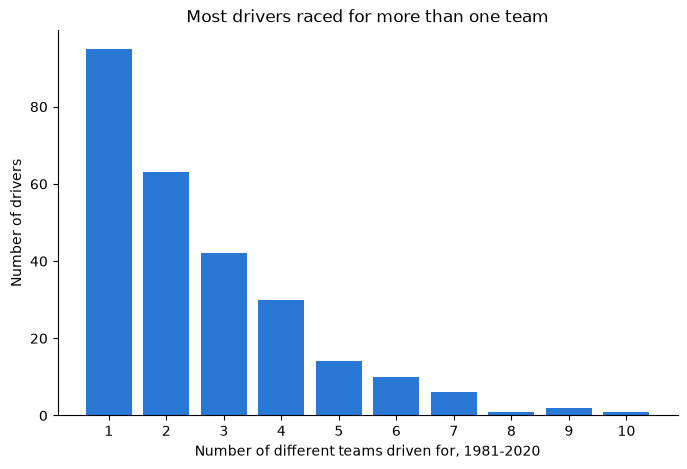

In [85]:
# Bar chart: how many drivers raced for 1 team, 2 teams, 3 teams, ...
team_counts = drivers_summary["Teams"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(team_counts.index, team_counts.values, color="#2a78d6")
plt.xticks(range(1, 11))
plt.xlabel("Number of different teams driven for, 1981-2020")
plt.ylabel("Number of drivers")
plt.title("Most drivers raced for more than one team")
plt.show()

In [86]:
# Do longer careers mean more teams? Put drivers into groups by career length.
drivers_summary["Career length"] = pd.cut(drivers_summary["Seasons"],
                                          bins=[0, 2, 5, 10, 40],
                                          labels=["1-2 seasons", "3-5 seasons",
                                                  "6-10 seasons", "11+ seasons"])
drivers_summary["Only one team"] = drivers_summary["Teams"] == 1

groups = drivers_summary.groupby("Career length", observed=True)
by_career = pd.DataFrame({
    "Drivers": groups["Teams"].count(),
    "Average number of teams": groups["Teams"].mean(),
    "Stayed with one team (%)": groups["Only one team"].mean() * 100,
})
by_career.round(1)

,Drivers,Average number of teams,Stayed with one team (%)
Career length,,,
1-2 seasons,128,1.4,68.0
3-5 seasons,58,2.5,13.8
6-10 seasons,48,4.2,0.0
11+ seasons,30,4.9,0.0


### (g) What do we learn from it?

Most drivers do not stay with a single team. Of the 264 drivers who raced between 1981 and 2020, only 95 (36%) drove for just one team, and the median driver raced for two. Staying with one team is mostly a sign of a short career: two-thirds of drivers with one or two seasons only had one team, but no driver who raced six or more seasons stayed with the same team the whole time. Drivers with 11 or more seasons raced for about five teams on average, and Andrea de Cesaris raced for ten. Moving between teams seems to be a normal part of a long F1 career.